# Pareto Plot — Accuracy vs. Length Reduction

Generates a single scatter + Pareto-front plot from a results CSV.  
Set the parameters in **Configuration**, then run all cells (`Run → Run All Cells`).

## 1 · Configuration

In [2]:
# ── USER PARAMETERS ────────────────────────────────────────────────────
CSV_PATH = "results_14B.csv"   # path to your CSV
MODE     = "average"            # "average" | "weighted"
SCALE    = "14B"               # label shown in the title (e.g. "1.5B", "7B")
OUT_PATH = None                 # None → auto name; or e.g. "pareto_7B.pdf"
FORMAT = "png"                  # "png" | "pdf"
DPI      = 1000                  


## 2 · Imports & Style

In [3]:
import csv
from pathlib import Path

import matplotlib
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

%matplotlib inline

matplotlib.rcParams.update({
    "font.family":       "sans-serif",
    "font.size":         11,
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "axes.grid":         True,
    "grid.color":        "white",
    "grid.linewidth":    0.7,
    "grid.alpha":        1.0,
})


## 3 · Colours & Marker Styles

In [4]:
# ── Mergenetic families ─────────────────────────────────────────────────
C_RANDOM   = "#0F60BD"   # deep blue     — Mergenetic Random
C_ENTROPY  = "#C62828"   # deep red      — Mergenetic Entropy
C_SINGLE   = "#840606"   # dark red      — Single-objective
C_PF_R     = "#64B5F6"   # light blue    — Pareto line Random
C_PF_E     = "#EF9A9A"   # light red     — Pareto line Entropy

# ── Endpoints ────────────────────────────────────────────────────────────
C_DEEPSEEK = "#3C56D9"
C_QWEN     = "#644FD7"

# ── Static merging (teal shades) ─────────────────────────────────────────
C_AVG_MERG = "#8CD5BD"
C_TASK_AR  = "#09979A"
C_TIES     = "#05564A"

# ── ACM (amber shades) ───────────────────────────────────────────────────
C_ACM_AVG  = "#EBC400"
C_ACM_TA   = "#EE9B00"
C_ACM_TIES = "#D06800"

ALPHA_ON  = 0.80
ALPHA_OFF = 0.30 
S_MERG    = 75
S_OTHER   = 75
S_ENDPT   = 75

STYLE = {
    "avg_merg": (C_AVG_MERG,  "s", S_OTHER),
    "task_ar":  (C_TASK_AR,   "s", S_OTHER),
    "ties":     (C_TIES,      "s", S_OTHER),
    "acm_avg":  (C_ACM_AVG,   "^", S_OTHER),
    "acm_ta":   (C_ACM_TA,    "^", S_OTHER),
    "acm_ties": (C_ACM_TIES,  "^", S_OTHER),
    "deepseek": (C_DEEPSEEK,  "D", S_ENDPT),
    "qwen":     (C_QWEN,      "D", S_ENDPT),
}

STATIC_CATS = {"avg_merg", "task_ar", "ties"}
ACM_CATS    = {"acm_avg", "acm_ta", "acm_ties"}
ENDPT_CATS  = {"deepseek", "qwen"}


## 4 · Helper Functions

In [5]:
def load_csv(path):
    with open(path) as f:
        return {row['method']: row for row in csv.DictReader(f)}


def classify(method):
    """Map a method name to its category key."""
    m = method.lower()
    if 'mergenetic' in m and ('accuracy' in m or 'length' in m): return 'single'
    if 'mergenetic' in m and 'random'  in m: return 'random'
    if 'mergenetic' in m and 'entropy' in m: return 'entropy'
    if 'acm-ta'   in m or 'acm_ta'   in m:  return 'acm_ta'
    if 'acm-ties' in m or 'acm_ties' in m:  return 'acm_ties'
    if 'acm'      in m:                      return 'acm_avg'
    if 'deepseek' in m:                      return 'deepseek'
    if 'qwen'     in m:                      return 'qwen'
    if any(x in m for x in ('task arithmetic','task-arithmetic','task_arithmetic')):
        return 'task_ar'
    if 'ties' in m:                          return 'ties'
    return 'avg_merg'


def len_reduction(row_len, ds_len):
    return (ds_len - row_len) / ds_len * 100


def pareto_front(points):
    """Return indices of non-dominated points (maximise acc, maximise len_red)."""
    pf = set()
    for i, (ai, ri) in enumerate(points):
        dominated = any(
            aj >= ai and rj >= ri and (aj > ai or rj > ri)
            for j, (aj, rj) in enumerate(points) if j != i
        )
        if not dominated:
            pf.add(i)
    return pf


def draw_pareto_line(ax, pts, color):
    if len(pts) < 2:
        return
    pts_sorted = sorted(pts, key=lambda p: p[1])
    xs = [p[1] for p in pts_sorted]
    ys = [p[0] for p in pts_sorted]
    ax.plot(xs, ys, color=color, lw=2.0, ls='-', alpha=0.75, zorder=4,
            solid_capstyle='round', solid_joinstyle='round')


def make_legend():
    def pt(color, marker='o', ms=8, **kw):
        return Line2D([0],[0], marker=marker, color='w',
                      markerfacecolor=color, markersize=ms, **kw)

    def spacer():
        return Line2D([0],[0], color='none', label=' ')

    return [
        pt(C_QWEN,      'D', 8,  label='Qwen2.5-Math'),
        pt(C_DEEPSEEK,  'D', 8,  label='DeepSeek-R1-Distill-Qwen'),
        spacer(), spacer(),
        pt(C_AVG_MERG,  's', 8,  label='Average Merging'),
        pt(C_TASK_AR,   's', 8,  label='Task Arithmetic'),
        pt(C_TIES,      's', 8,  label='TIES-Merging'),
        spacer(),
        pt(C_ACM_AVG,   '^', 9,  label='ACM-Average'),
        pt(C_ACM_TA,    '^', 9,  label='ACM-TA'),
        pt(C_ACM_TIES,  '^', 9,  label='ACM-TIES'),
        spacer(),
        pt(C_SINGLE,    '*', 12, label='Mergenetic – Single-obj.'),
        pt(C_ENTROPY,   'o', 9,  label='Mergenetic – Entropy'),
        pt(C_RANDOM,    'o', 9,  label='Mergenetic – Random'),
    ]


## 5 · Core Plot Function

In [6]:
def plot_pareto(ax, rows, acc_col, len_col, title, ylabel=True):
    """Populate ax with the full Pareto scatter."""
    ds_row = next(r for m, r in rows.items() if 'deepseek' in m.lower())
    ds_len = float(ds_row[len_col])
    ds_acc = float(ds_row[acc_col])

    groups = {k: [] for k in
              ('random','entropy','single',
               'avg_merg','task_ar','ties',
               'acm_avg','acm_ta','acm_ties',
               'deepseek','qwen')}

    for method, row in rows.items():
        acc = float(row[acc_col])
        lr  = len_reduction(float(row[len_col]), ds_len)
        groups[classify(method)].append((acc, lr))

    # Reference lines
    ax.axhline(ds_acc, color="black", lw=1.0, ls='--', alpha=0.5, zorder=1)
    ax.axvline(0,      color='#9E9E9E',  lw=0.6, ls=':',  alpha=0.50, zorder=1)

    # Static + ACM + endpoints
    for cat in list(STATIC_CATS) + list(ACM_CATS) + list(ENDPT_CATS):
        color, marker, size = STYLE[cat]
        zorder = 7 if cat in ENDPT_CATS else 5
        alpha  = ALPHA_ON
        for acc, lr in groups[cat]:
            ax.scatter(lr, acc, color=color, s=size, marker=marker,
                       zorder=zorder, alpha=alpha, linewidths=0)

    # Mergenetic Random / Entropy with Pareto dimming
    for pts, c_line, c_pt in [
        (groups['random'],  C_PF_R, C_RANDOM),
        (groups['entropy'], C_PF_E, C_ENTROPY),
    ]:
        if not pts:
            continue
        pf_idx = pareto_front(pts)
        draw_pareto_line(ax, [pts[i] for i in pf_idx], c_line)
        for i, (acc, lr) in enumerate(pts):
            in_pf = i in pf_idx
            ax.scatter(lr, acc, color=c_pt, s=S_MERG, marker='o',
                       alpha=ALPHA_ON if in_pf else ALPHA_OFF,
                       zorder=8 if in_pf else 6,
                       linewidths=0.8 if in_pf else 0,
                       edgecolors='white' if in_pf else 'none')

    # Mergenetic Single-obj
    for acc, lr in groups['single']:
        ax.scatter(lr, acc, color=C_SINGLE, s=S_MERG + 15, marker='*',
                   alpha=ALPHA_ON, zorder=7, linewidths=0)

    ax.set_title(title, fontsize=11, fontweight='semibold', pad=7)
    ax.set_xlabel('length reduction vs DeepSeek-R1 (%)', fontsize=9, labelpad=5)
    if ylabel:
        ax.set_ylabel('accuracy (%)', fontsize=9, labelpad=5)
    ax.tick_params(labelsize=8.5)

    all_lr = [lr for g in groups.values() for _, lr in g]
    if all_lr:
        ax.set_xlim(min(all_lr) - 3, max(all_lr) + 3)


## 6 · Generate Plot

Saved in pareto_14B_avg.png


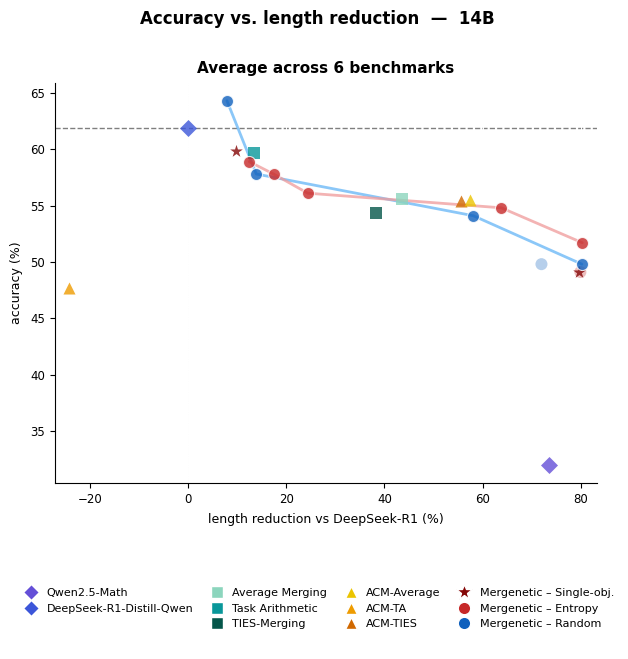

In [7]:
# ── Resolve column names from MODE ──────────────────────────────────────
if MODE == 'average':
    acc_col, len_col = 'Avg_acc', 'Avg_len'
    mode_label = 'Average'
elif MODE == 'weighted':
    acc_col, len_col = 'Weighted_acc', 'Weighted_len'
    mode_label = 'Weighted average'
else:
    raise ValueError(f"MODE must be 'average' or 'weighted', got: {MODE!r}")

# ── Auto output path ─────────────────────────────────────────────────────
if OUT_PATH is None:
    tag      = SCALE.replace('.', 'p')
    mode_tag = 'avg' if MODE == 'average' else 'weighted'
    out_path = Path(CSV_PATH).parent / f'pareto_{tag}_{mode_tag}.{FORMAT}'
else:
    out_path = Path(OUT_PATH)

# ── Load & plot ───────────────────────────────────────────────────────────
rows = load_csv(CSV_PATH)

fig, ax = plt.subplots(figsize=(7, 5.2))
fig.suptitle(
    f'Accuracy vs. length reduction  —  {SCALE}',
    fontsize=12, fontweight='semibold', y=1.02,
)

plot_pareto(ax, rows, acc_col, len_col, title=f'{mode_label} across 6 benchmarks', ylabel=True)

fig.legend(
    handles=make_legend(),
    loc='lower center', ncol=4, fontsize=8, frameon=False,
    bbox_to_anchor=(0.5, -0.22),
    handletextpad=0.4, columnspacing=1.1,
)

fig.savefig(out_path, bbox_inches='tight', dpi=DPI)
print(f'Saved in {out_path}')
plt.show()


---
## 7 · Benchmark-wise Comparison

Bar chart comparing **DeepSeek-R1-Distill**, **Qwen2.5-Math**, and the
**Mergenetic best-tradeoff** model per benchmark,
at both 1.5B and 7B scale.
The secondary axis shows the per-benchmark output-length reduction
of Mergenetic relative to DeepSeek-R1.

In [8]:
# ── USER PARAMETERS ────────────────────────────────────────────────────
CSV_1P5B      = "results_1p5B.csv"   # path to 1.5B results CSV
CSV_7B        = "results_7B.csv"     # path to 7B results CSV
CSV_14B       = "results_14B.csv"    # path to 14B results CSV
BENCH_MODE    = "average"            # "average" | "weighted"
BENCH_OUT     = None                 # None → auto; or e.g. "benchmark_comparison.pdf"
BENCH_FORMAT  = "png"                # "png" | "pdf"
BENCH_DPI     = 1000

# Best-tradeoff method name per scale (must match the CSV exactly)
BEST_1P5B = "Mergenetic-TA-05-Entropy"
BEST_7B   = "Mergenetic-TA-07-Entropy"
BEST_14B   = "Mergenetic-TA-05-Entropy"

Saved in benchmark_comparison_1p5B.png


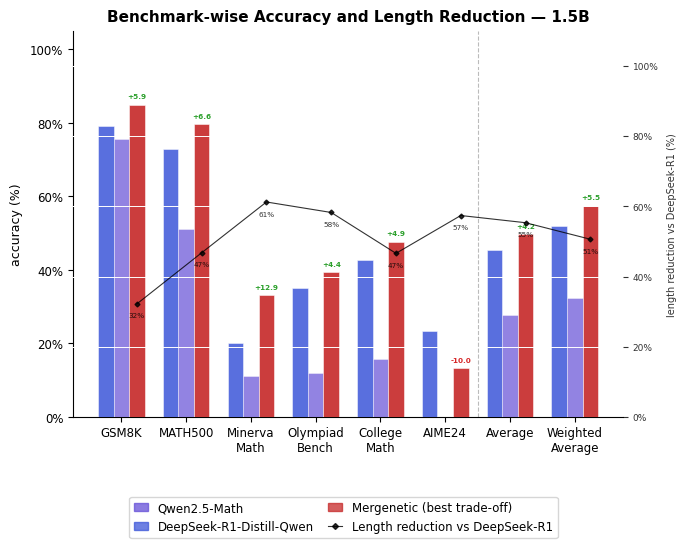

Saved in benchmark_comparison_7B.png


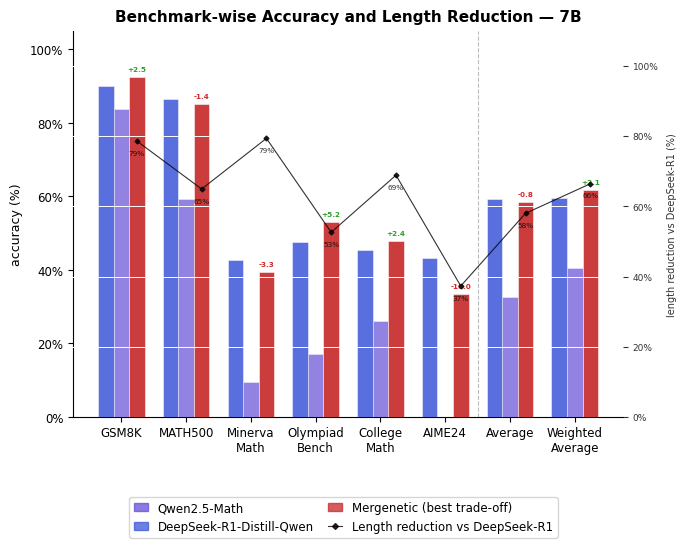

In [10]:
import matplotlib.ticker
import matplotlib.patches as mpatches
import numpy as np
from pathlib import Path

# ── colour palette (reuses constants defined in cell 3) ──────────────────
C_BAR_DS   = C_DEEPSEEK
C_BAR_QW   = C_QWEN
C_BAR_MG   = C_ENTROPY
C_LEN_LINE = "#000000CD"

BENCHMARKS = ["GSM8K", "MATH500", "Minerva\nMath",
              "Olympiad\nBench", "College\nMath", "AIME24",
              "Average", "Weighted\nAverage"]
BENCH_KEYS = ["GSM8K", "MATH500", "MinervaMath",
              "OlympiadBench", "CollegeMath", "AIME24"]


def _extract(rows, method, keys, acc_or_len):
    r = rows[method]
    vals = [float(r[f"{k}_{acc_or_len}"]) for k in keys]
    suffix = "acc" if acc_or_len == "acc" else "len"
    vals.append(float(r[f"Avg_{suffix}"]))
    vals.append(float(r[f"Weighted_{suffix}"]))
    return vals


def _len_red_per_bench(rows, method_mg, keys):
    ds_key = next(m for m in rows if "deepseek" in m.lower())
    mg_vals = _extract(rows, method_mg, keys, "len")
    ds_vals = _extract(rows, ds_key,   keys, "len")
    return [(d - m) / d * 100 for d, m in zip(ds_vals, mg_vals)]


def plot_bench_comparison(rows, method_ds, method_qw, method_mg, title):
    acc_ds = _extract(rows, method_ds, BENCH_KEYS, "acc")
    acc_qw = _extract(rows, method_qw, BENCH_KEYS, "acc")
    acc_mg = _extract(rows, method_mg, BENCH_KEYS, "acc")
    len_rd = _len_red_per_bench(rows, method_mg, BENCH_KEYS)

    fig, ax = plt.subplots(figsize=(7, 5.2))

    x      = np.arange(len(BENCHMARKS))
    w      = 0.24
    offsets = [-w, 0, w]

    # ── bars ──────────────────────────────────────────────────────────────
    ax.bar(x + offsets[0], acc_ds, width=w, color=C_BAR_DS, alpha=0.85,
           zorder=3, linewidth=0.4, edgecolor="white")
    ax.bar(x + offsets[1], acc_qw, width=w, color=C_BAR_QW, alpha=0.70,
           zorder=3, linewidth=0.4, edgecolor="white")
    ax.bar(x + offsets[2], acc_mg, width=w, color=C_BAR_MG, alpha=0.90,
           zorder=3, linewidth=0.4, edgecolor="white")

    ax.axvline(x=len(BENCH_KEYS) - 0.5, color="#bbbbbb",
               linewidth=0.8, linestyle="--", zorder=2)

    ax.set_xticks(x)
    ax.set_xticklabels(BENCHMARKS, fontsize=7.5)
    ax.set_ylim(0, 105)
    ax.set_yticks([0, 20, 40, 60, 80, 100])
    ax.yaxis.set_major_formatter(matplotlib.ticker.FormatStrFormatter("%g%%"))
    ax.tick_params(labelsize=8.5)
    ax.set_title(title, fontsize=11, fontweight="semibold", pad=7)
    ax.set_ylabel("accuracy (%)", fontsize=9, labelpad=5)

    # ── secondary axis (on top by default) ────────────────────────────────
    ax2 = ax.twinx()
    ax2.spines["top"].set_visible(False)
    ax2.spines["left"].set_visible(False)
    ax2.spines["bottom"].set_visible(False)
    ax2.spines["right"].set_color(C_LEN_LINE)
    ax2.tick_params(axis="y", colors=C_LEN_LINE, labelsize=6.5)
    ax2.set_ylim(0, 110)
    ax2.set_yticks([0, 20, 40, 60, 80, 100])
    ax2.yaxis.set_major_formatter(matplotlib.ticker.FormatStrFormatter("%g%%"))
    ax2.set_ylabel("length reduction vs DeepSeek-R1 (%)",
                   color=C_LEN_LINE, fontsize=7, labelpad=6)

    len_x = x + offsets[2]
    ax2.plot(len_x, len_rd, color=C_LEN_LINE, linewidth=0.8,
             marker="D", markersize=2.5, zorder=5)
    for xi, lr in zip(len_x, len_rd):
        ax2.text(xi, lr - 2.5, f"{lr:.0f}%", ha="center", va="top",
                 fontsize=5.2, color=C_LEN_LINE, fontweight="normal")

    # ── acc delta annotations (drawn on ax2 so they appear above the line) ─
    # convert y from ax scale (0–105) to ax2 scale (0–110)
    y_scale = ax2.get_ylim()[1] / ax.get_ylim()[1]
    for i_b, (mg_v, ds_v) in enumerate(zip(acc_mg, acc_ds)):
        diff = mg_v - ds_v
        col  = "#2CA02C" if diff > 0 else "#d62728"
        sign = "+" if diff > 0 else ""
        ax2.text(x[i_b] + offsets[2], mg_v * y_scale + 1.5,
                 f"{sign}{diff:.1f}", ha="center", va="bottom",
                 fontsize=5.2, color=col, fontweight="bold")

    # ── legend ────────────────────────────────────────────────────────────
    bar_handles = [
        mpatches.Patch(color=C_BAR_QW, alpha=0.75, label="Qwen2.5-Math"),
        mpatches.Patch(color=C_BAR_DS, alpha=0.75, label="DeepSeek-R1-Distill-Qwen"),
        mpatches.Patch(color=C_BAR_MG, alpha=0.75, label="Mergenetic (best trade-off)"),
        matplotlib.lines.Line2D([0], [0], color=C_LEN_LINE, marker="D",
                                 markersize=3, linewidth=0.8,
                                 label="Length reduction vs DeepSeek-R1"),
    ]
    fig.legend(handles=bar_handles, loc="lower center", ncol=2,
               bbox_to_anchor=(0.5, -0.06), frameon=True,
               columnspacing=1.2, handlelength=1.2, fontsize=8.5)

    fig.tight_layout(rect=[0, 0.08, 1, 1])
    return fig


# ── Load data ─────────────────────────────────────────────────────────────
rows_1p5b = load_csv(CSV_1P5B)
rows_7b   = load_csv(CSV_7B)
#rows_14b  = load_csv(CSV_14B)

ds_1p5b = next(m for m in rows_1p5b if "deepseek" in m.lower())
qw_1p5b = next(m for m in rows_1p5b if "qwen"    in m.lower())
ds_7b   = next(m for m in rows_7b   if "deepseek" in m.lower())
qw_7b   = next(m for m in rows_7b   if "qwen"    in m.lower())
#ds_14b  = next(m for m in rows_14b  if "deepseek" in m.lower())
#qw_14b  = next(m for m in rows_14b  if "qwen"    in m.lower())

# ── Generate & save individual figures ────────────────────────────────────
for rows, ds, qw, best, scale in [
    (rows_1p5b, ds_1p5b, qw_1p5b, BEST_1P5B, "1p5B"),
    (rows_7b,   ds_7b,   qw_7b,   BEST_7B,   "7B"),
    #(rows_14b,  ds_14b,  qw_14b,  BEST_14B,  "14B"),
]:
    fig = plot_bench_comparison(rows, ds, qw, best,
                                title=f"Benchmark-wise Accuracy and Length Reduction — {scale.replace('p', '.')}")
    out = Path(BENCH_OUT) if BENCH_OUT else \
          Path(CSV_1P5B).parent / f"benchmark_comparison_{scale}.{BENCH_FORMAT}"
    fig.savefig(out, bbox_inches="tight", dpi=BENCH_DPI)
    print(f"Saved in {out}")
    plt.show()